# mplfinance vs mplchart

[mplfinance](https://github.com/matplotlib/mplfinance) is the standard matplotlib finance extension, with a lineage going back to matplotlib itself: it descends from the `matplotlib.finance` module that once shipped inside the library, was spun off as `mpl_finance` when deprecated out of core, and was then rewritten around the modern `mpf.plot` API and relaunched as mplfinance in 2019 — maintained under the matplotlib GitHub organization ever since. It is mature, feature-rich, widely deployed, and the natural default for financial plotting with matplotlib.

mplchart is an experimental library with a different design center: declarative chart composition with built-in indicators, on pandas or polars data. Both render classic financial charts with matplotlib, so they embed anywhere matplotlib does — scripts, notebooks, GUI apps, saved images.

This page is a factual comparison, with the same chart built in each. mplchart's interface is still evolving; mplfinance is the stable, established choice.


In [1]:
import mplfinance as mpf

from mplchart.chart import Chart
from mplchart.primitives import Candlesticks, HeikinAshi, Renko, Volume
from mplchart.indicators import SMA
from mplchart.samples import sample_prices

prices = sample_prices()                                 # lower-case columns, full history
data = prices.tail(250).rename(columns=str.capitalize)   # mplfinance wants Capitalized columns
prices.tail(3)

,open,high,low,close,volume
date,,,,,
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.489990,265.730011,267.459991,42862157


## The same chart in both

Candlesticks, volume, and two moving averages — first mplfinance, then mplchart.

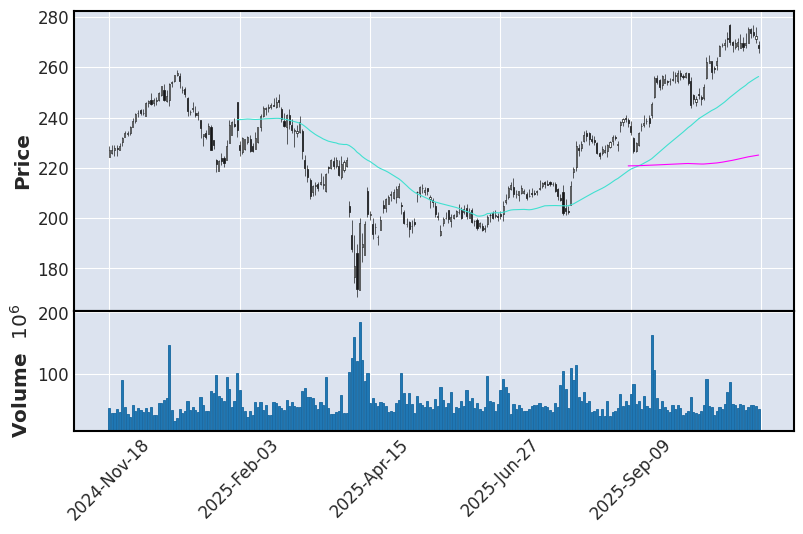

In [2]:
mpf.plot(data, type="candle", mav=(50, 200), volume=True, figsize=(10, 6))

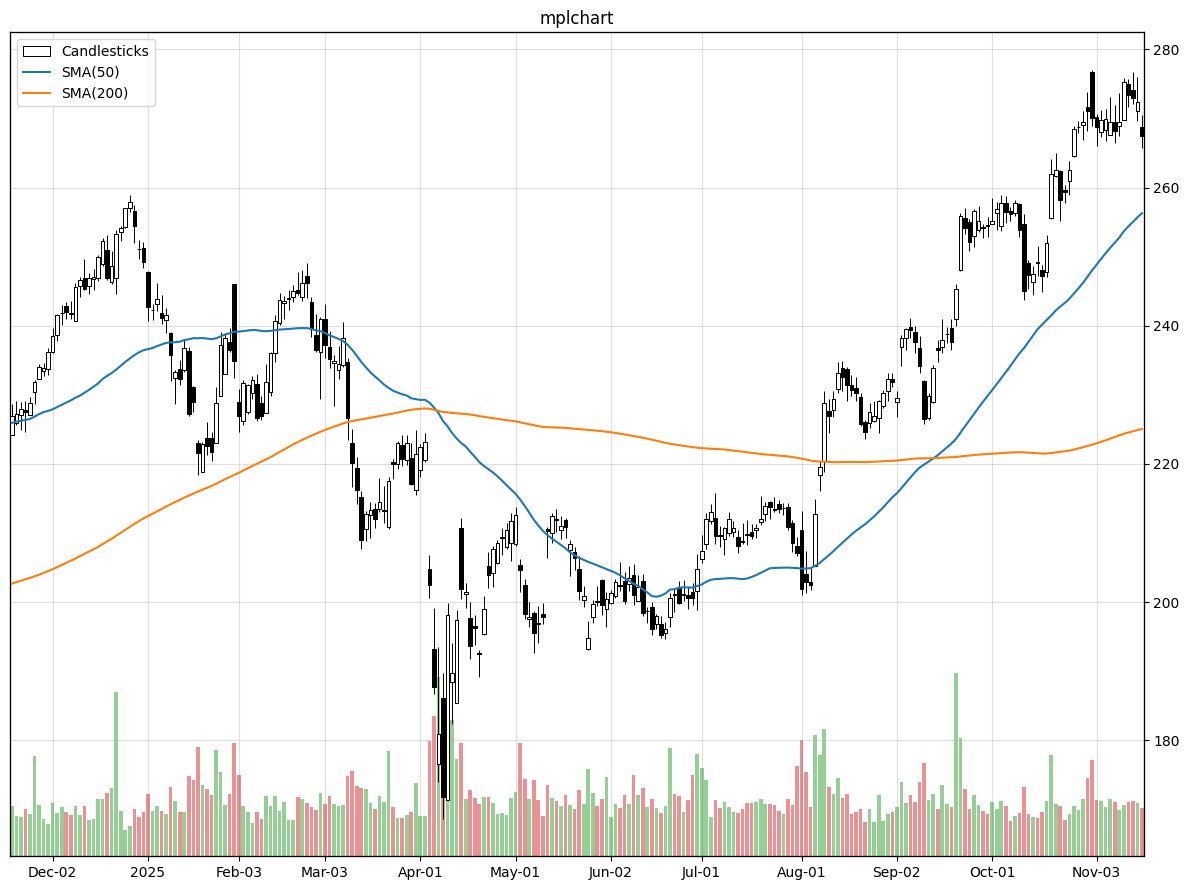

In [3]:
Chart(prices, title="mplchart", max_bars=250).plot(
    Candlesticks(), Volume(), SMA(50), SMA(200),
).show()

Same ingredients, two API styles: mplfinance is *option-driven* — one `mpf.plot(...)` call configured through keyword arguments (`type=`, `mav=`, `volume=`). mplchart is *composition-driven* — a chart is a list of primitives and indicators, extended by adding items or panes.

One difference is visible above: on the mplfinance chart the 200-bar average only covers the last 50 bars. That is structural, not a tuning issue — see *The data is the view* below.


## Data conventions

| | mplfinance | mplchart |
|---|---|---|
| Backend | pandas | pandas **or polars** |
| Columns | `Open`, `High`, `Low`, `Close`, `Volume` (capitalized) | `open`, `high`, `low`, `close`, `volume` (lower case) |
| Dates | `DatetimeIndex` | datetime index (pandas) or `date`/`datetime` column |
| Mismatched names | rename yourself | `Chart(..., normalize=True)` |

The polars support is a real differentiator if your pipeline is polars-based: mplchart consumes polars frames natively (with polars expressions instead of indicators — see the backends reference page), no conversion to pandas needed.

## The data is the view

In mplfinance, the data you pass *is* the view: `mpf.plot` shows exactly the frame it receives, and any computation happens on that window. Moving averages inherit this — `mav=(50, 200)` computes over the plotted slice, so on a 250-bar window the 200-bar average only exists for the last 50 bars, as seen in the first chart. The warm-up truncation is structural: there is no data outside the view to compute from. And beyond `mav=`/`ema=`, everything enters as *pre-calculated* data through `mpf.make_addplot(...)` — the user computes the indicator, slices it to the plotted window, and keeps it aligned by hand.

mplchart separates the data from the view: `Chart(prices, max_bars=250)` keeps the full history, indicators compute on the fly over that whole range, and only then are the results sliced to the visible window. A 200-bar average is fully formed at the left edge of a 250-bar chart, and resizing the window never changes indicator values.


## Non-trading gaps

Both libraries can draw price history without weekend and holiday gaps, via different mechanisms. mplfinance controls it with a flag — `show_nontrading=False` is the default, and passing `True` restores calendar spacing. mplchart eliminates gaps *by construction*: bars are positioned by row number and the date axis maps tick labels back to dates, so gapless is the default; `Chart(..., raw_dates=True)` opts into raw calendar spacing instead.

## Chart types

Both libraries now cover the box-based chart types. mplfinance renders them through `type=`: `candle`, `ohlc`, `line`, `hollow_and_filled`, `renko`, `pnf`. mplchart composes primitives: `Candlesticks` (including hollow modes), `OHLC`, line/area/bar plots, `HeikinAshi`, `Renko`, and `PointFigure`. Heikin-Ashi is mplchart-only; mplfinance draws hollow candles but not averaged ones.

The deeper difference is the design. mplfinance transforms inside the plot call — `mav=` is specially wired to compute over renko bricks, but that is where indicator support on box charts ends. mplchart's `Renko` and `PointFigure` are *transform* primitives: they rebase the chart onto bricks or columns, and everything after them — any indicator, volume, extra panes — composes in the transformed space with no special wiring. The window (`max_bars`) counts bricks, and an `SMA(20)` is an average of the last 20 bricks, time-free by construction.


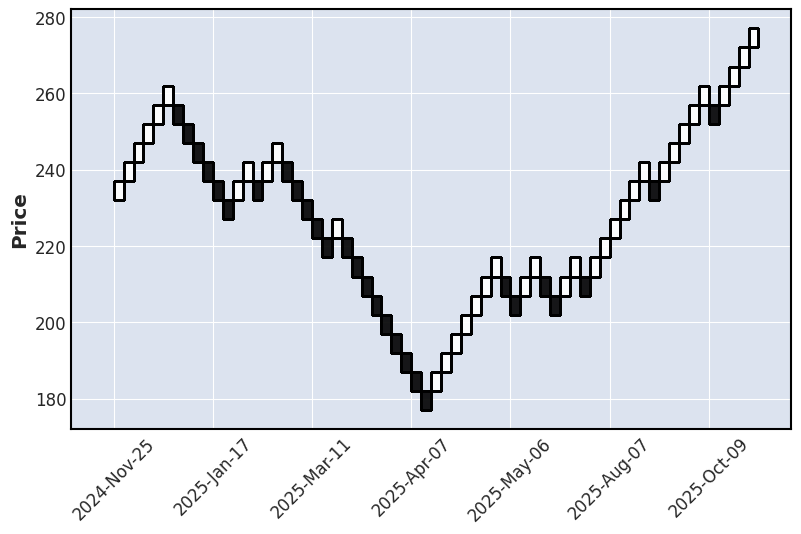

In [4]:
mpf.plot(data, type="renko", renko_params=dict(brick_size=5), figsize=(10, 6))

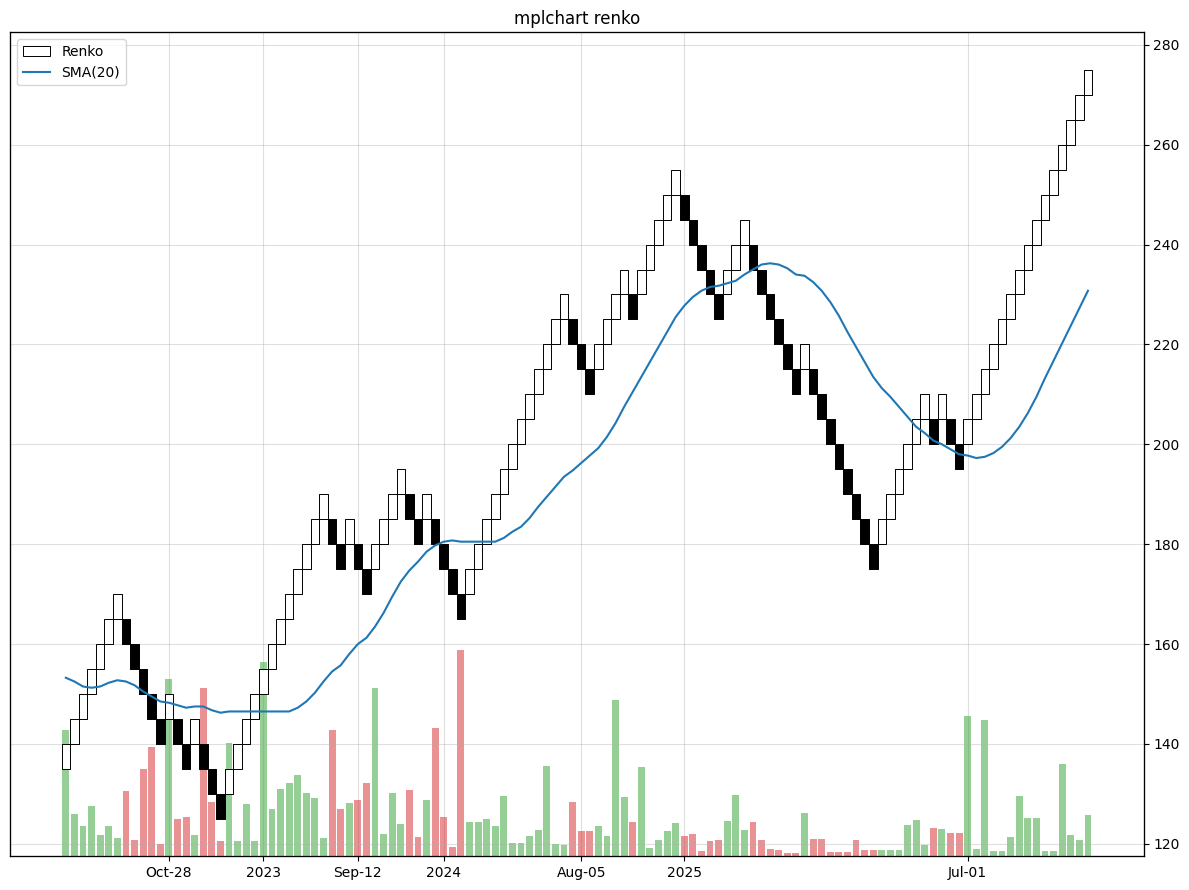

In [5]:
Chart(prices, title="mplchart renko", max_bars=120).plot(
    Renko(brick_size=5), SMA(20), Volume(),
).show()


## Indicators

mplfinance ships moving averages (`mav=`, `ema=`) built in; anything else you compute yourself and attach with `mpf.make_addplot(...)`, which gives full control at the cost of manual wiring (computed and window-aligned by hand — see *The data is the view*). mplchart ships a library of indicators (`RSI`, `MACD`, `BBANDS`, ATR-family, and more) that slot directly into the chart with automatic panes, plus polars expression equivalents, condition primitives (`Stripes`, `Markers`), and support for custom callables. If your charts are indicator-heavy, this is where the declarative style pays off.

## Styling

Both ship a style system with named presets. mplfinance has a few dozen (`yahoo`, `charles`, `binance`, `blueskies`, ...) plus `make_mpf_style` for custom ones. mplchart resolves a single `style=` argument through several layers: shipped styles by name (`nightclouds`, `chartist`, `modern`, ...), any matplotlib stylesheet name (`ggplot`, `dark_background`, ...), provider-prefixed names — `style="mpf:yahoo"` renders mplfinance's own styles directly, `style="mt:economist"` a [morethemes](https://github.com/y-sunflower/morethemes) theme — or an ad-hoc spec combining rc params with finance-specific settings (`candle.up.color`, `wicks.color`, ...). mplchart styles are *total*: ambient rcParams never leak into a chart, so the same code renders identically everywhere.


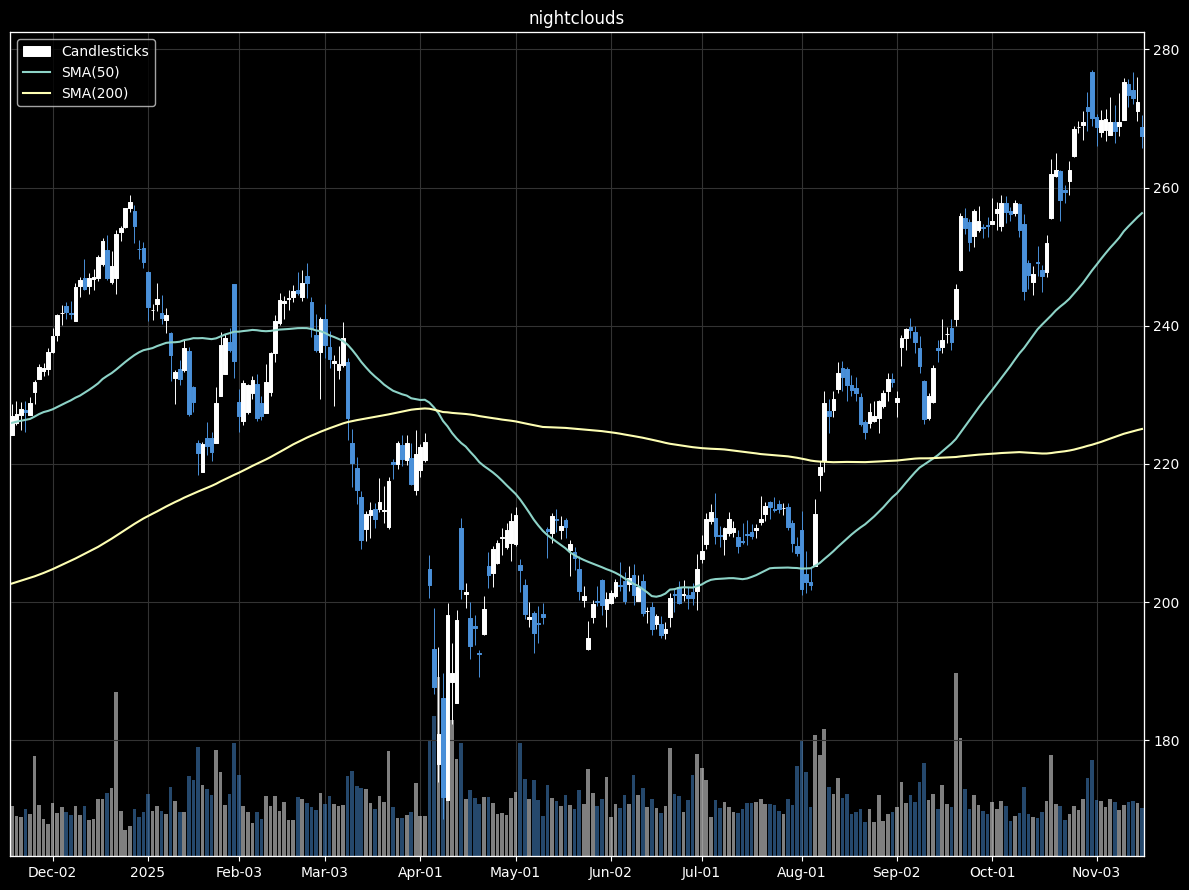

In [6]:
Chart(prices, title="nightclouds", max_bars=250, style="nightclouds").plot(
    Candlesticks(), Volume(), SMA(50), SMA(200),
).show()
